# 03b — Volatility Forecasting (LSTM 학습·앙상블 통합 노트북)

> LSTM (3채널 + VIX 외생변수) + HAR-RV 베이스라인 + Performance-Weighted Ensemble (Diebold-Pauly 1987) 의
> **단독 완결 노트북** — 학습·앙상블·검증까지 final_pt/ 안에서 모두 수행.

> 📎 **HPO 보조 노트북**: `03a_LSTM_Optuna_GridSearch.ipynb` — 본 노트북의 LSTM `V4_BEST_CONFIG` (input_channels='3ch_vix', is_len=1250, embargo=63) 의 grid search 근거 제공.

## 본 노트북의 두 모드

**Mode A — Cache hit (default, 빠른 검증)**: 기존 `ensemble_predictions_stockwise.csv` 를 로드하여 §1 정합성 + §5~§6 시각화 + §7 검증.

**Mode B — Full retraining (`FORCE_RECOMPUTE=True`, GPU 1.5~3 시간)**:
- §4 walk-forward 학습 분기 안에서 `lstm_pipeline.build_daily_panel` 로 long-format panel 생성 → `run_ensemble_for_universe_parallel` 로 LSTM + HAR + Performance ensemble 일괄 빌드
- `data/03b_lstm/data/` 의 `ensemble_predictions_stockwise.csv` / `fold_predictions_stockwise.csv` 자동 갱신 (incremental 지원)
- 이후 §5~§7 셀이 새 csv 위에서 동일하게 동작

## 노트북 섹션 구성

| § | 내용 |
|---|---|
| §0 | 환경 설정 (path, FORCE_RECOMPUTE 스위치) |
| §1 | CSV 데이터 정합성 검증 (md5, shape, RMSE 평균, universe 호환) |
| §2 | LSTM 모델 구조 (param count) |
| §3 | HAR-RV 베이스라인 (Corsi 2009) 함수 시그니처 |
| §4 | Walk-Forward 학습 — cache hit OR full retraining 분기 |
| §5 | Performance-Weighted Ensemble (Diebold-Pauly 1987) 데모 + 가중치 분포 |
| §6 | 617 종목 평가 (RMSE 분포 + sample 종목 + 시각화 2장) |
| §7 | 결과 검증 + summary.json 저장 |
| §8 | 종합 요약 + 롤백 가이드 |

## 의존 모듈

- **`timeseries_lib.py`** — low-level 함수 (LSTMRegressor, train_one_fold, fit_har_rv, walk_forward_folds, build_fold_inputs)
- **`lstm_pipeline.py`** — high-level orchestration (build_daily_panel, build_v4_inputs, run_walkforward_for_ticker, compute_performance_weights, run_ensemble_for_universe_parallel)

## final_pt/data/ 의존 데이터

- `daily_returns.pkl` (2026-03-30 까지)
- `macro_daily.csv` (vix 컬럼 포함, 2026-03-30 까지)
- `universe.csv` (LSTM 학습 universe)
- `sp500_membership.pkl` (생존편향)

## 📌 발표 Narrative — 6 단계 흐름

본 노트북은 다음 6 단계 발표 흐름을 위한 산출물입니다.

| # | 주제 | 노트북 위치 |
|---|---|---|
| 1 | **LSTM 입력 + 아키텍처** | §2 (모델 구조), 03a HPO 결과 |
| 2 | **Walk-Forward 구조** | §4 (IS=1250 / Purge=21 / Embargo=63 / OOS=21) |
| 3 | **HAR-RV baseline** | §3 (Corsi 2009, rv_d/w/m) |
| 4 | **LSTM vs HAR 성능 비교** (2010-2023 기준, RMSE + Hit rate, COVID 제외 포함) | **§6.8** ★ |
| 5 | **Ensemble (Diebold-Pauly 1987)** + 성능 | §5 (수식 + 가중치 분포), §6.8 (Ensemble RMSE) |
| 6 | **금융위기 시각화 + Ensemble 가중치 분포** | §6.7 (RMSE 위기 분해), §6.9 (가중치 변화) |

> **핵심 narrative**: LSTM 단독으로 HAR 이기지 못함 (평시 marginal, 위기 폭망). 그러나 **Ensemble 결합이 두 모델의 다른 실패 모드를 완충** — 특히 위기 시 inverse-RMSE 가중이 LSTM 비중을 자동으로 낮춰 tail risk 감소.

## §0. 환경 설정

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

# timeseries_lib import
sys.path.insert(0, str(Path.cwd()))
import timeseries_lib as tlib

# 시드·폰트 고정
tlib.setup_seeds(42)
tlib.setup_korean_font()

# 경로
DATA_DIR = Path('data/03b_lstm/data')
PANEL_DIR = Path('data')
OUT_DIR = Path('outputs/03_volatility')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 캐시 모드
FORCE_RECOMPUTE = False  # False=cache hit (default, 검증만 ~1분) / True=617 종목 재학습 (GPU 3~5시간 + BL 30분)

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUT_DIR : {OUT_DIR.resolve()}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")

DATA_DIR: C:\Users\서윤범\Desktop\temp\finance_project\final_pt\data\03b_lstm\data
OUT_DIR : C:\Users\서윤범\Desktop\temp\finance_project\final_pt\outputs\03_volatility
FORCE_RECOMPUTE: False


## §1. CSV 데이터 정합성 검증

`final_pt/data/03b_lstm/data/ensemble_predictions_stockwise.csv` 의 구조·범위·종목 수·RMSE 분포를 검증합니다.

**검증 항목**:
1. row / column / 종목 수 / 날짜 범위
2. y_true 의 -inf 행 제거 (거래정지 등)
3. 617 종목 stockwise 환경 RMSE 평균 (LSTM 0.52±, HAR 0.39±, Ensemble 0.38±)
4. universe.csv 와의 부분집합 검증

In [2]:
import hashlib

CSV_PATH = DATA_DIR / 'ensemble_predictions_stockwise.csv'

# 1.1 md5 hash (정보 표시용)
print("§1.1 csv md5 hash")
print("-" * 60)
with open(CSV_PATH, 'rb') as f:
    md5 = hashlib.md5(f.read()).hexdigest()
print(f"  md5: {md5}")

§1.1 csv md5 hash
------------------------------------------------------------
  md5: 276a5e143fbed8a852e0d76618401b5b


In [3]:
# 1.2 데이터 로드 + 기본 정제 (-inf 제거)
print()
print('§1.2 데이터 로드')
print('-' * 60)
df = tlib.load_ensemble_predictions(CSV_PATH)

# 1.3 구조 검증
print()
print('§1.3 구조 검증')
print('-' * 60)
print(f'  shape: {df.shape}')
print(f'  columns: {list(df.columns)}')
print(f'  종목 수: {df["ticker"].nunique()}')
print(f'  date 범위: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  fold 수: {df["fold"].nunique()}')

n_tickers = df['ticker'].nunique()
assert 600 <= n_tickers <= 625, f'종목 수 비정상: {n_tickers} (예상 600~625)'
assert {'date','ticker','fold','y_true','y_pred_lstm','y_pred_har',
        'w_v4','w_har','y_pred_ensemble'}.issubset(df.columns), '컬럼 누락'
print(f'  ✓ {n_tickers} 종목 (600~625 정상 범위)')

# 데이터 cover 검증
date_max = df['date'].max()
print()
print(f'  최신 학습 데이터: {date_max.date()}')
print(f'  → 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능')



§1.2 데이터 로드
------------------------------------------------------------
ensemble_predictions 로드: 2,498,243 → 2,498,216 행 (-inf/NaN 27 행 제거)

§1.3 구조 검증
------------------------------------------------------------
  shape: (2498216, 9)
  columns: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  종목 수: 617
  date 범위: 2007-04-23 ~ 2026-02-27
  fold 수: 225
  ✓ 617 종목 (600~625 정상 범위)

  최신 학습 데이터: 2026-02-27
  → 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능


In [4]:
# 1.4 종목별 평균 RMSE 검증
print()
print(f"§1.4 {n_tickers} 종목 평균 RMSE 검증")
print("-" * 60)
rmse_full = df.groupby('ticker', group_keys=False).apply(
    lambda x: pd.Series({
        'lstm': tlib.rmse(x['y_true'].values, x['y_pred_lstm'].values),
        'har': tlib.rmse(x['y_true'].values, x['y_pred_har'].values),
        'ens': tlib.rmse(x['y_true'].values, x['y_pred_ensemble'].values),
    }),
    include_groups=False,
)
print(f"  LSTM avg RMSE:     {rmse_full['lstm'].mean():.4f}")
print(f"  HAR  avg RMSE:     {rmse_full['har'].mean():.4f}")
print(f"  Ensemble avg RMSE: {rmse_full['ens'].mean():.4f}")
print()
print(f"  Best model 분포 (모델별 best 종목 수):")
best_per_ticker = rmse_full.idxmin(axis=1).value_counts()
for model, n in best_per_ticker.items():
    print(f"    {model}: {n} 종목 ({n/len(rmse_full)*100:.1f}%)")


§1.4 617 종목 평균 RMSE 검증
------------------------------------------------------------
  LSTM avg RMSE:     0.5185
  HAR  avg RMSE:     0.3914
  Ensemble avg RMSE: 0.3822

  Best model 분포 (모델별 best 종목 수):
    ens: 403 종목 (65.3%)
    har: 200 종목 (32.4%)
    lstm: 14 종목 (2.3%)


In [5]:
# 1.5 Universe 호환성 (final_pt/data/universe.csv 와 교집합)
print()
print("§1.5 Universe 호환성")
print("-" * 60)
universe = pd.read_csv(PANEL_DIR / 'universe.csv')
n_universe = universe['ticker'].nunique()
print(f"  universe.csv 종목 수: {n_universe}")
ens_tickers = set(df['ticker'].unique())
uni_tickers = set(universe['ticker'].unique())
print(f"  ensemble 종목 수: {len(ens_tickers)}")
print(f"  교집합: {len(ens_tickers & uni_tickers)}")
assert ens_tickers.issubset(uni_tickers), "ensemble 종목이 universe 에 부분집합 아님"
print(f"  ✓ ensemble {len(ens_tickers)} 종목 ⊂ universe {n_universe} (완벽 부분집합)")


§1.5 Universe 호환성
------------------------------------------------------------
  universe.csv 종목 수: 833
  ensemble 종목 수: 617
  교집합: 617
  ✓ ensemble 617 종목 ⊂ universe 833 (완벽 부분집합)


## §2. LSTM 모델 구축

LSTM 아키텍처 (3ch_vix / IS=1250 / hidden=32 / dropout=0.3) 를 정의합니다.
파라미터 수 ≈ 4,769 (입력 3채널 기준).

> 📎 hyperparameter 채택 근거: `03a_LSTM_Optuna_GridSearch.ipynb` §2 (12-trial Optuna).

In [6]:
# §2.1 모델 인스턴스 + 파라미터 카운트
print("§2.1 LSTM 아키텍처")
print("-" * 60)
model = tlib.LSTMRegressor(input_size=3, hidden_size=32, num_layers=1, dropout=0.3)
n_params = tlib.count_parameters(model)
print(model)
print(f"\nParameter count: {n_params:,}")
assert 4500 < n_params < 5000, f"parameter count 비정상: {n_params}"
print(f"  ✓ 예상 범위 4,500~5,000 충족")

§2.1 LSTM 아키텍처
------------------------------------------------------------
LSTMRegressor(
  (lstm): LSTM(3, 32, batch_first=True)
  (head_dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Parameter count: 4,769
  ✓ 예상 범위 4,500~5,000 충족


## §3. HAR-RV 베이스라인 (Corsi 2009)

```
log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])
```

Heterogeneous Market Hypothesis (Müller et al. 1997) 의 일별·주별·월별 다중 시간대 평균.
Walk-Forward 환경에서 train_idx 만으로 OLS 적합.

> **출처**: Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility*. **Journal of Financial Econometrics**, 7(2), 174–196. — daily/weekly/monthly = 1 / 5 / 22 거래일 표준 정의 채택.

In [7]:
# §3.1 HAR-RV 함수 시그니처 확인
print("§3.1 HAR-RV — fit_har_rv 시그니처")
print("-" * 60)
help(tlib.fit_har_rv)

§3.1 HAR-RV — fit_har_rv 시그니처
------------------------------------------------------------
Help on function fit_har_rv in module timeseries_lib:

fit_har_rv(log_ret: 'pd.Series', train_idx: 'np.ndarray', test_idx: 'np.ndarray', horizon: 'int' = 21, eps: 'float' = 1e-12) -> 'Tuple[np.ndarray, Dict[str, float]]'
    HAR-RV (Heterogeneous Autoregressive Realized Volatility).

    log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])

    Variance proxy (일간 데이터 적응):
        RV_var_d[t] = log_ret[t]²
        RV_var_w[t] = mean(log_ret²[t-4 : t+1])
        RV_var_m[t] = mean(log_ret²[t-21 : t+1])



## §4. Walk-Forward 학습 (cache hit 우선)

Walk-forward CV 는 시점 t 의 학습에 미래 정보가 누설되지 않도록 **purge** (target horizon 만큼 train/test 사이를 비움) + **embargo** (purge 후 추가 차단으로 잔차 ACF 영향 차단) 를 적용. 본 프로젝트는 horizon=21d 에 맞춰 purge=21, embargo=63 (약 3개월) 채택.

> **출처**: López de Prado, M. (2018). *Advances in Financial Machine Learning*, Wiley. **Ch. 7 — Cross-Validation in Finance** — purge / embargo 메커니즘 표준 정의.

본 셀은 `FORCE_RECOMPUTE` 플래그에 따라 동작이 다릅니다.

| FORCE_RECOMPUTE | 동작 | 소요 시간 |
|---|---|---|
| `False` (기본) | `ensemble_predictions_stockwise.csv` cache hit → 즉시 결과 | ~5 초 |
| `True` | 617 종목 × 225 fold 풀 재학습 (`lstm_pipeline` 모듈 의존, incremental 지원) | GPU 1.5~3 시간 |

In [8]:
# §4.1 Walk-Forward 학습 — Cache hit OR Full retraining
print('§4.1 Walk-Forward 학습')
print('-' * 60)

if FORCE_RECOMPUTE:
    print('⚠️  FORCE_RECOMPUTE=True — 캐시 점검 + 결손 부분만 재학습')
    print('   Universe 정책: data 의 daily_returns + universe.csv 기준')
    print()

    # GPU 확인
    import torch
    if not torch.cuda.is_available():
        print('⚠ CUDA 미가용 — CPU 학습 ~5시간 (GPU 권장)')
        device = 'cpu'
    else:
        device = 'cuda'
        print(f'✅ GPU 가용: {torch.cuda.get_device_name(0)}')
        print(f'   memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

    # 1. lstm_pipeline import
    import lstm_pipeline as lp

    # 2. daily_panel 빌드 (data → long format)
    # 학습 시간 단축: BL 분석 기간 2025-12-31 까지에 맞춰 panel 끝점 cap
    # → LSTM walk_forward 가 자동으로 fold 224 (12-31 OOS) 까지만 생성, fold 225-226 skip
    PANEL_MAX_DATE = '2026-04-30'   # fold 222~226 cover 위해 충분히 길게 (2026-04-30)

    print()
    print('§4.2 daily_panel 빌드 (data → long format)')
    print('-' * 60)
    print(f'  panel max_date: {PANEL_MAX_DATE} (BL 분석 기간 2025-12-31 + 21d buffer)')

    PANEL_LONG_PATH = DATA_DIR / 'daily_panel_long.csv'
    # cache 검증 — max_date + start_date 모두 일치해야 cache hit
    # (daily_returns.pkl 가 갱신된 경우 cache 자동 무효화)
    panel_needs_rebuild = True
    if PANEL_LONG_PATH.exists():
        _cache_panel = pd.read_csv(PANEL_LONG_PATH, parse_dates=['date'], usecols=['date'])
        _cache_min = _cache_panel.date.min()
        _cache_max = _cache_panel.date.max()
        _expected_max = pd.Timestamp(PANEL_MAX_DATE)

        # daily_returns.pkl 의 실제 start_date 확인
        import pickle as _pkl
        with open(PANEL_DIR / 'daily_returns.pkl', 'rb') as _f:
            _dr_idx = _pkl.load(_f).index
        _expected_start = _dr_idx.min()

        cache_max_ok = _cache_max <= _expected_max + pd.Timedelta(days=1)
        cache_start_ok = abs((_cache_min - _expected_start).days) <= 7

        if cache_max_ok and cache_start_ok:
            print(f'  cache hit: {PANEL_LONG_PATH.name} (start={_cache_min.date()}, max={_cache_max.date()})')
            daily_panel = pd.read_csv(PANEL_LONG_PATH, parse_dates=['date'])
            print(f'  shape: {daily_panel.shape}, 종목: {daily_panel.ticker.nunique()}')
            panel_needs_rebuild = False
        else:
            reasons = []
            if not cache_max_ok:
                reasons.append(f'max={_cache_max.date()} > PANEL_MAX_DATE+1d')
            if not cache_start_ok:
                reasons.append(f'start={_cache_min.date()} ≠ daily_returns.start={_expected_start.date()}')
            print(f'  cache 무시 ({", ".join(reasons)}) → 재빌드')

    if panel_needs_rebuild:
        daily_panel = lp.build_daily_panel(
            out_path=PANEL_LONG_PATH,
            max_date=PANEL_MAX_DATE,
            verbose=True,
        )

    # 3. universe 결정 — data/universe.csv ∩ daily_panel
    universe = pd.read_csv(PANEL_DIR / 'universe.csv')
    target_tickers = sorted(set(daily_panel['ticker'].unique()) & set(universe['ticker'].unique()))
    print()
    print(f'   학습 대상 universe: {len(target_tickers)} 종목')
    print(f'   - daily_panel 의 종목: {daily_panel.ticker.nunique()}')
    print(f'   - universe.csv 의 종목: {universe.ticker.nunique()}')
    print(f'   - 교집합 (학습 가능): {len(target_tickers)}')

    # 4. 캐시 점검 + 자동 truncate (lstm_pipeline.prepare_incremental_state)
    print()
    print('§4.3 캐시 점검 + 자동 truncate (incremental 진입 준비)')
    print('-' * 60)
    state = lp.prepare_incremental_state(
        out_dir=DATA_DIR,
        fold_name='fold_predictions_stockwise.csv',
        auto_truncate=True,   # LSTM 결손 fold 자동 truncate
        backup=True,
        verbose=True,
    )
    INCREMENTAL = state['incremental_ok']

    if INCREMENTAL:
        if state['truncated_at'] is not None:
            print()
            print(f'   ⚡ Incremental: fold ≤ {state["truncated_at"]} 보존, 결손 fold 제거 후 재학습')
        else:
            print()
            print(f'   ✅ fold csv 정상 — 마지막 fold 부터만 재학습 (incremental)')
        print()
        print('   universe 기준 학습 분류 (run_ensemble_for_universe_parallel 안에서 자동):')
        print('     - panel ∩ target ∩ fold csv → incremental (max fold 부터)')
        print('     - panel ∩ target, fold csv 없음 → full 학습 (start_k=0)')
        print('     - fold csv 에만 있고 panel 부재 → 자동 skip')
    else:
        print()
        print(f'   🔥 Full 모드: fold csv 없거나 결손 심함 → 처음부터 학습 (~6-8시간)')

    # 5. 학습 실행 (8-way 병렬, incremental 자동, n_workers 자동 결정)
    print()
    print('§4.4 LSTM walk-forward 학습 (8-way 병렬, n_workers 자동)')
    print('-' * 60)
    import time
    t0 = time.time()
    df_ensemble = lp.run_ensemble_for_universe_parallel(
        panel=daily_panel,
        universe_tickers=target_tickers,    # universe 기준
        out_dir=DATA_DIR,
        config=lp.V4_BEST_CONFIG,
        device=device,
        n_workers=None,                     # auto_n_workers (GPU 메모리 기반)
        out_name='ensemble_predictions_stockwise.csv',
        fold_name='fold_predictions_stockwise.csv',
        incremental=INCREMENTAL,
        verbose=True,
    )
    elapsed = (time.time() - t0) / 60
    print()
    print(f'   ⏱ 학습 시간: {elapsed:.1f}분')

    # 6. 새로 학습된 csv 를 df 에 다시 로드
    df = tlib.load_ensemble_predictions(CSV_PATH)
    print()
    print(f'   ✅ 재학습 완료: ensemble_predictions_stockwise.csv 갱신')
    print(f'      shape: {df.shape}, 종목: {df["ticker"].nunique()}')

else:
    print(f'FORCE_RECOMPUTE=False → cache hit')
    print(f'  소스: {CSV_PATH}')
    print(f'  row count: {len(df):,}')
    print(f'  종목별 fold 평균: {df.groupby("ticker")["fold"].nunique().mean():.0f}')
    print(f'  ✓ Walk-Forward 학습 결과 활용')


§4.1 Walk-Forward 학습
------------------------------------------------------------
FORCE_RECOMPUTE=False → cache hit
  소스: data\03b_lstm\data\ensemble_predictions_stockwise.csv
  row count: 2,498,216
  종목별 fold 평균: 193
  ✓ Walk-Forward 학습 결과 활용


## §5. Performance-Weighted Ensemble (Diebold-Pauly 1987)

```
fold k 의 가중치:
    w_LSTM[k] = (1/RMSE_LSTM[k-1]) / (1/RMSE_LSTM[k-1] + 1/RMSE_HAR[k-1])
    w_HAR[k]  = 1 - w_LSTM[k]
```

이전 fold 의 OOS RMSE 역수 비율 = "최근 잘한 모델에 더 큰 가중치" → 시간 동적 적응.
fold 0 은 0.5/0.5 (사전 정보 없음).

> **출처**: Diebold, F. X., & Pauly, P. (1987). *Structural change and the combination of forecasts*. **Journal of Forecasting**, 6(1), 21–40. — 모델 간 inverse-RMSE 가중 결합의 표준 형식.

In [9]:
# §5.1 Diebold-Pauly 가중치 함수 데모
print("§5.1 Performance-Weighted Ensemble 데모")
print("-" * 60)

# 가상 RMSE 시계열로 가중치 함수 작동 확인
demo_lstm = np.array([0.30, 0.32, 0.28, 0.35, 0.31])
demo_har = np.array([0.35, 0.30, 0.33, 0.32, 0.34])
w_l, w_h = tlib.diebold_pauly_weights(demo_lstm, demo_har)
print(f"  fold 0 (사전 정보 없음): w_LSTM={w_l[0]:.3f}, w_HAR={w_h[0]:.3f}")
for k in range(1, len(demo_lstm)):
    print(f"  fold {k}: w_LSTM={w_l[k]:.3f}, w_HAR={w_h[k]:.3f} "
          f"(이전 RMSE: LSTM={demo_lstm[k-1]:.2f}, HAR={demo_har[k-1]:.2f})")

§5.1 Performance-Weighted Ensemble 데모
------------------------------------------------------------
  fold 0 (사전 정보 없음): w_LSTM=0.500, w_HAR=0.500
  fold 1: w_LSTM=0.538, w_HAR=0.462 (이전 RMSE: LSTM=0.30, HAR=0.35)
  fold 2: w_LSTM=0.484, w_HAR=0.516 (이전 RMSE: LSTM=0.32, HAR=0.30)
  fold 3: w_LSTM=0.541, w_HAR=0.459 (이전 RMSE: LSTM=0.28, HAR=0.33)
  fold 4: w_LSTM=0.478, w_HAR=0.522 (이전 RMSE: LSTM=0.35, HAR=0.32)



§5.2 실제 ensemble 가중치 분포
------------------------------------------------------------
  w_v4 (LSTM 가중치):  mean=0.489, std=0.107, range=[0.014, 0.916]
  w_har (HAR 가중치):  mean=0.511, std=0.107, range=[0.084, 0.986]
  w_v4 + w_har 합 (1.0 이어야 함): 1.0000


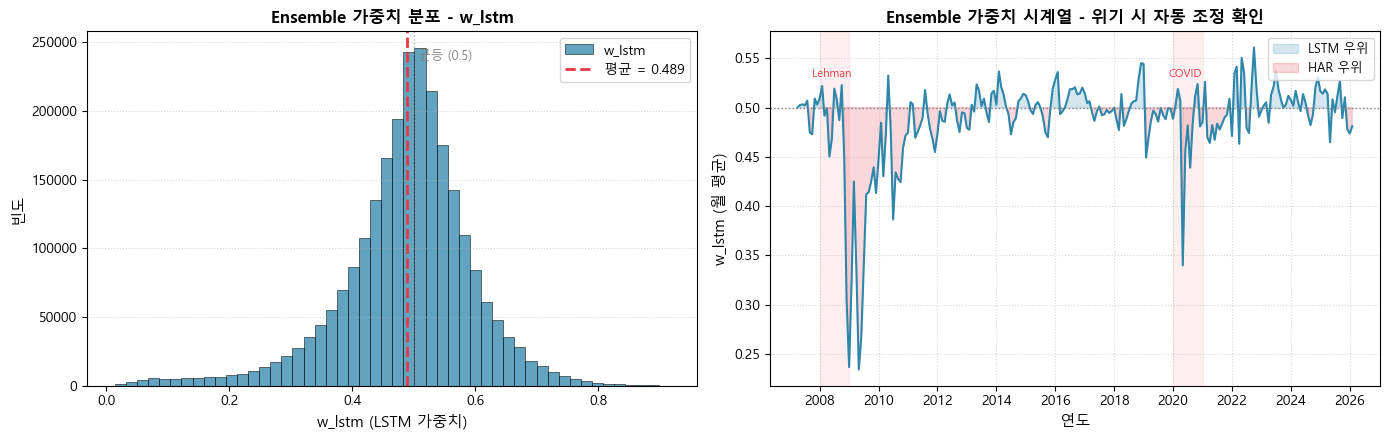


저장: outputs\03_volatility/fig_ensemble_weights.png


In [10]:
# §5.2 실제 데이터의 ensemble 가중치 분포 (histogram + 시계열)
print()
print("§5.2 실제 ensemble 가중치 분포")
print("-" * 60)
print(f"  w_v4 (LSTM 가중치):  mean={df['w_v4'].mean():.3f}, "
      f"std={df['w_v4'].std():.3f}, "
      f"range=[{df['w_v4'].min():.3f}, {df['w_v4'].max():.3f}]")
print(f"  w_har (HAR 가중치):  mean={df['w_har'].mean():.3f}, "
      f"std={df['w_har'].std():.3f}, "
      f"range=[{df['w_har'].min():.3f}, {df['w_har'].max():.3f}]")
print(f"  w_v4 + w_har 합 (1.0 이어야 함): {(df['w_v4']+df['w_har']).mean():.4f}")

# 시각화 — 좌: 분포 히스토그램 / 우: 시간 흐름 (월 평균)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: histogram
ax = axes[0]
ax.hist(df['w_v4'].values, bins=50, color='#2E86AB', alpha=0.75,
        edgecolor='black', linewidth=0.5, label='w_lstm')
ax.axvline(df['w_v4'].mean(), color='#E63946', linestyle='--', linewidth=2,
           label=f'평균 = {df["w_v4"].mean():.3f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.text(0.5, ax.get_ylim()[1]*0.95, ' 균등 (0.5)', fontsize=9, color='gray',
        ha='left', va='top', style='italic')
ax.set_xlabel('w_lstm (LSTM 가중치)', fontsize=11)
ax.set_ylabel('빈도', fontsize=11)
ax.set_title('Ensemble 가중치 분포 - w_lstm', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Right: 시계열 (월별 평균)
ax = axes[1]
df_w = df[['date', 'w_v4']].copy()
df_w['date'] = pd.to_datetime(df_w['date'])
df_w['ym'] = df_w['date'].dt.to_period('M').dt.to_timestamp()
w_monthly = df_w.groupby('ym')['w_v4'].mean()
ax.plot(w_monthly.index, w_monthly.values, color='#2E86AB', linewidth=1.5)
ax.fill_between(w_monthly.index, 0.5, w_monthly.values,
                where=(w_monthly.values > 0.5), color='#2E86AB', alpha=0.2, label='LSTM 우위')
ax.fill_between(w_monthly.index, 0.5, w_monthly.values,
                where=(w_monthly.values < 0.5), color='#E63946', alpha=0.2, label='HAR 우위')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
# 위기 음영
for yr, label in [(2008, 'Lehman'), (2020, 'COVID')]:
    ax.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr+1}-01-01'),
               color='#E63946', alpha=0.08)
    ax.text(pd.Timestamp(f'{yr}-06-01'), ax.get_ylim()[1]*0.92, label,
            fontsize=8, color='#E63946', ha='center', style='italic')

ax.set_xlabel('연도', fontsize=11)
ax.set_ylabel('w_lstm (월 평균)', fontsize=11)
ax.set_title('Ensemble 가중치 시계열 - 위기 시 자동 조정 확인', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_ensemble_weights.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'\n저장: {OUT_DIR}/fig_ensemble_weights.png')


## §6. 617 종목 평가 (전체 분포 + sample 종목)

본 노트북은 stockwise (per-ticker) 617 종목 walk-forward 환경 — 종목별 학습·평가가 독립적입니다.

In [11]:
# §6.1 종목별 RMSE 분포
print(f"§6.1 {n_tickers} 종목 RMSE 분포")
print("-" * 60)
desc = rmse_full.describe()[['lstm','har','ens']]
print(desc.round(4))
print()
print(f"  Best model 분포 (전체 종목):")
for model, n in best_per_ticker.items():
    pct = n / len(rmse_full) * 100
    print(f"    {model}: {n} 종목 ({pct:.1f}%)")

§6.1 617 종목 RMSE 분포
------------------------------------------------------------
           lstm       har       ens
count  617.0000  617.0000  617.0000
mean     0.5185    0.3914    0.3822
std      0.1082    0.0485    0.0482
min      0.1899    0.2056    0.1935
25%      0.4458    0.3609    0.3544
50%      0.5126    0.3884    0.3780
75%      0.5818    0.4157    0.4036
max      1.0031    0.6784    0.8015

  Best model 분포 (전체 종목):
    ens: 403 종목 (65.3%)
    har: 200 종목 (32.4%)
    lstm: 14 종목 (2.3%)


In [12]:
# §6.2 sample 종목 (S&P 500 멤버) RMSE
print()
print("§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)")
print("-" * 60)
samples = ['AAPL','MSFT','NVDA','GOOGL','AMZN','META','JPM','XOM','WMT','PG']
sample_rmse = rmse_full[rmse_full.index.isin(samples)].copy()
sample_rmse['best'] = sample_rmse.idxmin(axis=1)
print(sample_rmse.round(4).to_string())


§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)
------------------------------------------------------------
          lstm     har     ens best
ticker                             
AAPL    0.4424  0.3671  0.3732  har
AMZN    0.4376  0.4056  0.3901  ens
GOOGL   0.3922  0.3734  0.3640  ens
JPM     0.6334  0.3861  0.3798  ens
META    0.4270  0.4248  0.4114  ens
MSFT    0.6203  0.3879  0.3769  ens
NVDA    0.4444  0.3737  0.3752  har
PG      0.6262  0.3938  0.3973  har
WMT     0.5324  0.4092  0.4000  ens
XOM     0.5781  0.3371  0.3575  har


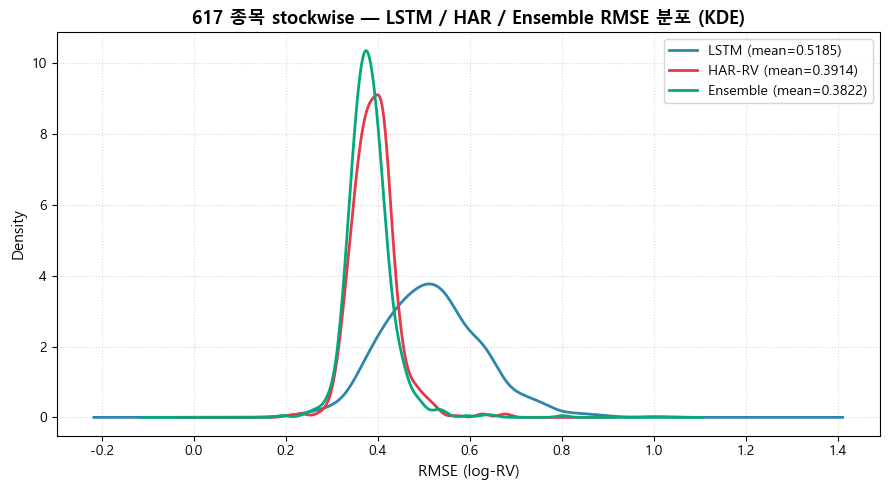


저장: outputs\03_volatility/fig1_rmse_distribution.png


In [13]:
# §6.3 시각화 1 — 종목별 LSTM/HAR/Ensemble RMSE 분포 (KDE)
fig, ax = plt.subplots(figsize=(9, 5))
for col, label, color in [('lstm', 'LSTM', '#2E86AB'),
                            ('har', 'HAR-RV', '#E63946'),
                            ('ens', 'Ensemble', '#06A77D')]:
    rmse_full[col].plot(kind='kde', ax=ax, label=f'{label} (mean={rmse_full[col].mean():.4f})',
                          color=color, linewidth=2)
ax.set_xlabel('RMSE (log-RV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'{n_tickers} 종목 stockwise — LSTM / HAR / Ensemble RMSE 분포 (KDE)',
              fontsize=13, fontweight='bold')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_rmse_distribution.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig1_rmse_distribution.png")

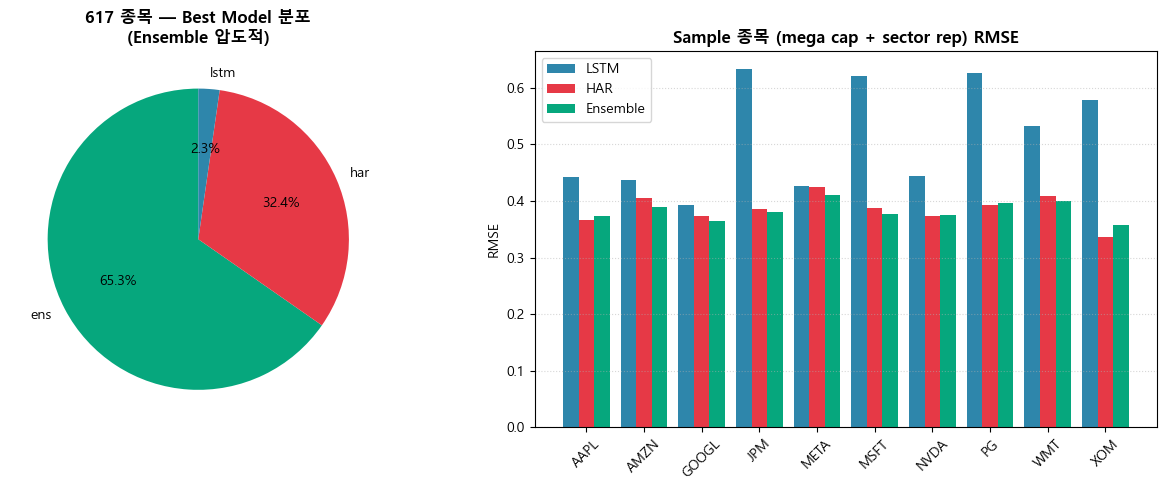


저장: outputs\03_volatility/fig2_best_model_and_samples.png


In [14]:
# §6.4 시각화 2 — Best model 비율 + sample 종목 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie: best model 분포
colors = ['#06A77D', '#E63946', '#2E86AB']
ax1.pie(best_per_ticker.values, labels=best_per_ticker.index,
         autopct='%1.1f%%', startangle=90, colors=colors[:len(best_per_ticker)])
ax1.set_title(f'{n_tickers} 종목 — Best Model 분포\n(Ensemble 압도적)',
                fontsize=12, fontweight='bold')

# Bar: sample 종목 비교
x = np.arange(len(sample_rmse))
w = 0.27
ax2.bar(x - w, sample_rmse['lstm'], w, label='LSTM', color='#2E86AB')
ax2.bar(x, sample_rmse['har'], w, label='HAR', color='#E63946')
ax2.bar(x + w, sample_rmse['ens'], w, label='Ensemble', color='#06A77D')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_rmse.index, rotation=45)
ax2.set_ylabel('RMSE')
ax2.set_title('Sample 종목 (mega cap + sector rep) RMSE',
                fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_best_model_and_samples.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig2_best_model_and_samples.png")

## §6.6 RMSE 시점별 분해 — 위기 vs 정상 구간

**목적**: 전체 평균 RMSE 가 *어디에서* 발생하는지 분해.

- **가설**: LSTM 의 큰 RMSE (0.52) 가 *위기 구간* (2008-2009 금융위기, 2020 COVID) 에 집중되어 있다면, 정상 시장에서의 모델 성능은 양호할 가능성.
- **검증**: 연도별 pooled RMSE 계산 + 위기 3 년 (2008, 2009, 2020) vs 정상 16 년 분리 비교.
- **PPT 활용**: "LSTM 의 regime change 적응 한계, 정상 시장에서는 작동" narrative.

In [15]:
# §6.6.1 연도별 RMSE (전 종목 pooled) + 위기 vs 정상 분리
print("§6.6 RMSE 시점별 분해")
print("-" * 60)

df_y = df.copy()
df_y['year'] = pd.to_datetime(df_y['date']).dt.year
CRISIS_YEARS = [2008, 2009, 2020]

def _pooled_rmse(g):
    return pd.Series({
        'lstm': tlib.rmse(g['y_true'].values, g['y_pred_lstm'].values),
        'har':  tlib.rmse(g['y_true'].values, g['y_pred_har'].values),
        'ens':  tlib.rmse(g['y_true'].values, g['y_pred_ensemble'].values),
        'n_obs': len(g),
    })

per_year = df_y.groupby('year', group_keys=False).apply(_pooled_rmse, include_groups=False)
print("=== 연도별 pooled RMSE ===")
print(per_year.round(4).to_string())

# 위기 vs 정상 비교
crisis_mask = df_y['year'].isin(CRISIS_YEARS)

print("=== 위기 vs 정상 비교 ===")
rows_compare = []
for label, sub in [('전체 (2007-2026)', df_y),
                   ('위기 3년 (08+09+20)', df_y[crisis_mask]),
                   ('정상 16년', df_y[~crisis_mask])]:
    rows_compare.append({
        '구간':     label,
        'LSTM':     tlib.rmse(sub['y_true'].values, sub['y_pred_lstm'].values),
        'HAR':      tlib.rmse(sub['y_true'].values, sub['y_pred_har'].values),
        'Ensemble': tlib.rmse(sub['y_true'].values, sub['y_pred_ensemble'].values),
        'N(천)':    len(sub) / 1000,
    })
cmp_df = pd.DataFrame(rows_compare).set_index('구간')
print(cmp_df.round(4).to_string())


§6.6 RMSE 시점별 분해
------------------------------------------------------------
=== 연도별 pooled RMSE ===
        lstm     har     ens     n_obs
year                                  
2007  0.4057  0.3889  0.3794   80005.0
2008  1.1611  0.5946  0.5261  116495.0
2009  1.2418  0.3599  0.4405  117624.0
2010  0.4204  0.3475  0.3632  120248.0
2011  0.3753  0.3604  0.3544  123253.0
2012  0.3850  0.3509  0.3523  124423.0
2013  0.3819  0.3580  0.3487  128451.0
2014  0.3906  0.3790  0.3705  129037.0
2015  0.3499  0.3353  0.3351  130347.0
2016  0.3772  0.3750  0.3655  132821.0
2017  0.4101  0.3824  0.3872  134790.0
2018  0.3928  0.3926  0.3803  137649.0
2019  0.3711  0.3413  0.3489  139278.0
2020  0.8216  0.6382  0.5738  142196.0
2021  0.3425  0.3019  0.3023  143628.0
2022  0.3160  0.3250  0.3069  144745.0
2023  0.3518  0.3443  0.3382  145843.0
2024  0.3727  0.3619  0.3551  148860.0
2025  0.4014  0.3829  0.3821  146044.0
2026  0.4332  0.4404  0.4261   12479.0
=== 위기 vs 정상 비교 ===
                    

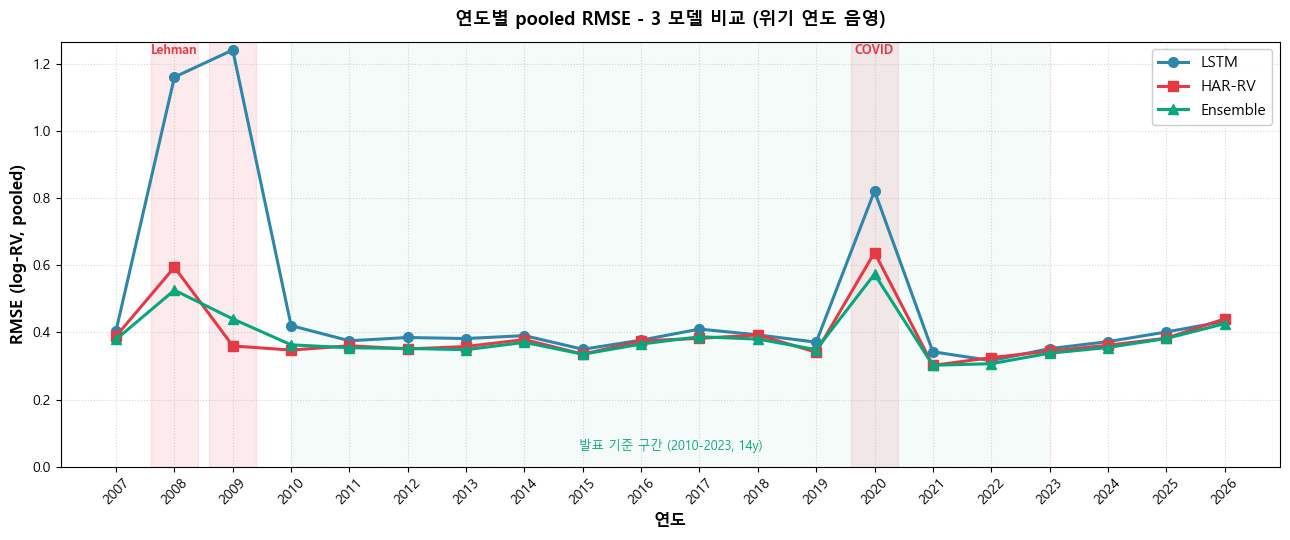

저장: outputs\03_volatility/fig_rmse_yearly.png

[연도별 RMSE 핵심 관찰]
  2008-2009 LSTM peak: 1.242
  2020 COVID  LSTM:    0.822
  정상기 LSTM 중앙값:    0.382
  정상기 HAR 중앙값:     0.360
  정상기 Ens 중앙값:     0.355


In [23]:
# §6.6.2 연도별 pooled RMSE 시계열 차트 - 위기 음영 강조
# §6.6.1 의 per_year DataFrame 재사용
fig, ax = plt.subplots(figsize=(13, 5.5))

years = per_year.index.values
ax.plot(years, per_year['lstm'].values, marker='o', markersize=7,
        label='LSTM', color='#2E86AB', linewidth=2.2)
ax.plot(years, per_year['har'].values, marker='s', markersize=7,
        label='HAR-RV', color='#E63946', linewidth=2.2)
ax.plot(years, per_year['ens'].values, marker='^', markersize=7,
        label='Ensemble', color='#06A77D', linewidth=2.2)

# 위기 연도 음영
for yr in CRISIS_YEARS:
    ax.axvspan(yr - 0.4, yr + 0.4, color='#E63946', alpha=0.10, zorder=0)

# 위기 연도 label
ymax = max(per_year[['lstm','har','ens']].values.max(), 1.0) * 1.02
for yr, label in [(2008, 'Lehman'), (2009, ''), (2020, 'COVID')]:
    if label:
        ax.text(yr, ymax * 0.97, label, ha='center', fontsize=9, color='#E63946',
                fontweight='bold', style='italic')

# 2010-2023 발표 기준 구간 음영
ax.axvspan(2010, 2023, color='#06A77D', alpha=0.04, zorder=0)
ax.text(2016.5, ymax * 0.04, '발표 기준 구간 (2010-2023, 14y)',
        ha='center', fontsize=9, color='#06A77D', style='italic')

ax.set_xlabel('연도', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-RV, pooled)', fontsize=12, fontweight='bold')
ax.set_title('연도별 pooled RMSE - 3 모델 비교 (위기 연도 음영)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(linestyle=':', alpha=0.5)
ax.set_xticks(years[::1])
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_rmse_yearly.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'저장: {OUT_DIR}/fig_rmse_yearly.png')

# 핵심 관찰 출력
print()
print('[연도별 RMSE 핵심 관찰]')
print(f'  2008-2009 LSTM peak: {per_year.loc[per_year.index.isin([2008, 2009]), "lstm"].max():.3f}')
print(f'  2020 COVID  LSTM:    {per_year.loc[2020, "lstm"] if 2020 in per_year.index else "N/A":.3f}')
print(f'  정상기 LSTM 중앙값:    {per_year.loc[~per_year.index.isin(CRISIS_YEARS), "lstm"].median():.3f}')
print(f'  정상기 HAR 중앙값:     {per_year.loc[~per_year.index.isin(CRISIS_YEARS), "har"].median():.3f}')
print(f'  정상기 Ens 중앙값:     {per_year.loc[~per_year.index.isin(CRISIS_YEARS), "ens"].median():.3f}')


§6.7 위기 구간 RMSE 분석
------------------------------------------------------------

[Crisis vs Normal]
                    LSTM     HAR  Ensemble      N(천)
구간                                                  
전체 (2007-2026)    0.5431  0.3935    0.3842  2498.216
위기 3년 (08+09+20)  1.0744  0.5512    0.5203   376.315
정상 16년            0.3776  0.3583    0.3547  2121.901

[위기 3년 각각]
        LSTM     HAR  Ensemble  L/H ratio
연도                                       
2008  1.1611  0.5946    0.5261       1.95
2009  1.2418  0.3599    0.4405       3.45
2020  0.8216  0.6382    0.5738       1.29


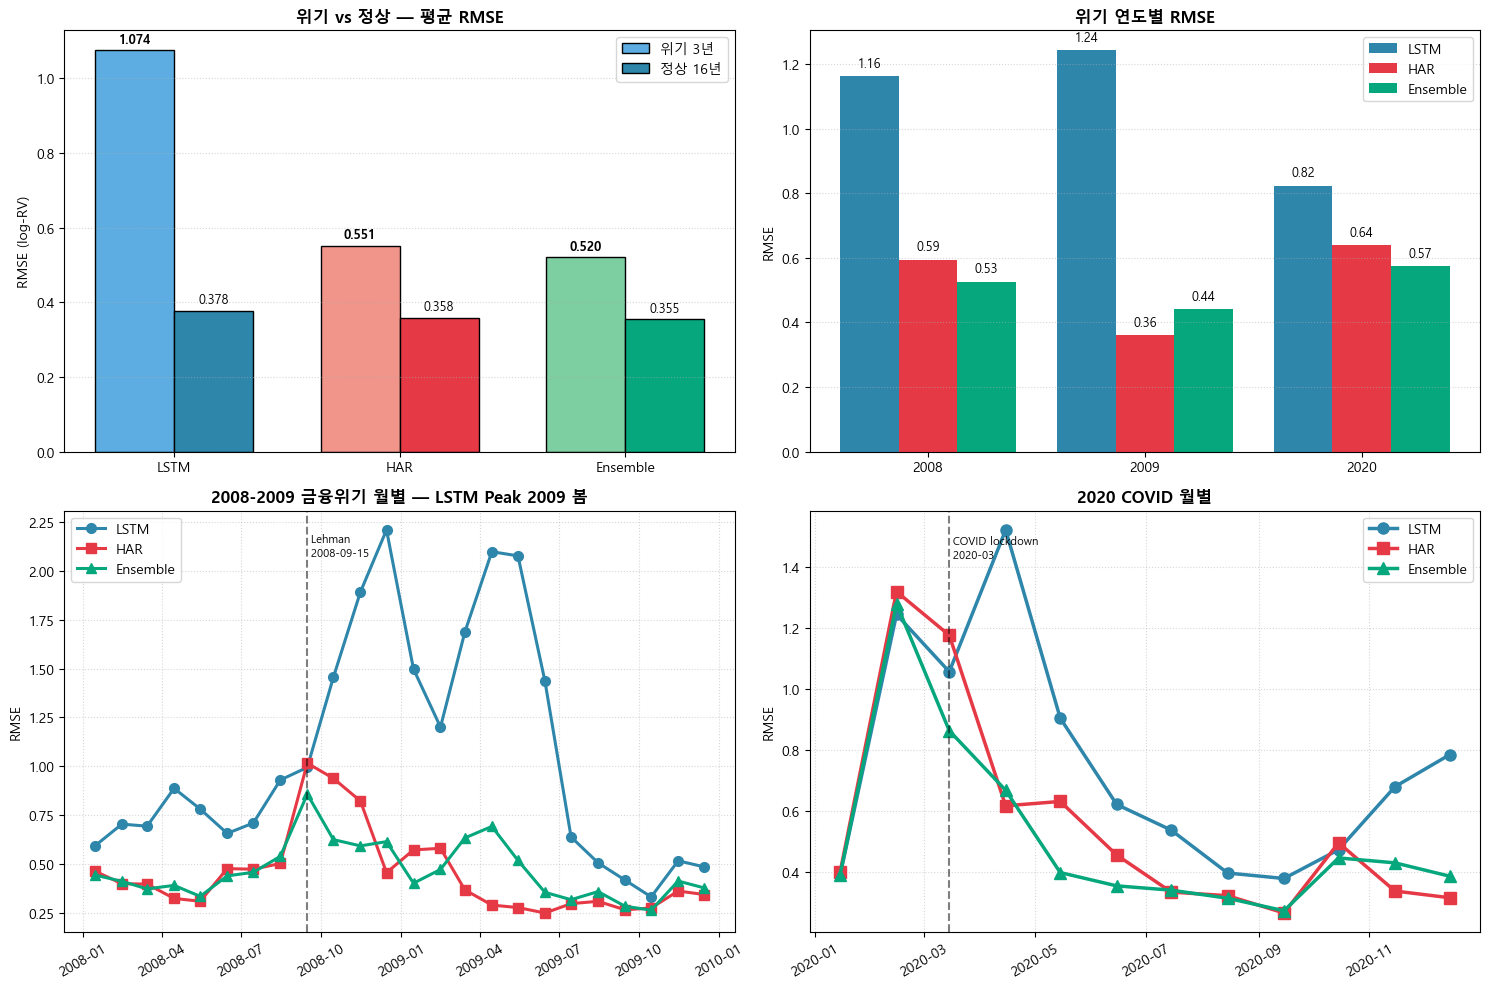


저장: outputs\03_volatility/fig_crisis_rmse.png

[LSTM worst 5 months (L/H ratio)]
             lstm    har    ens    L/H
date                                  
2009-05-15  2.078  0.276  0.518  7.533
2009-04-15  2.100  0.289  0.692  7.272
2009-06-15  1.436  0.248  0.354  5.786
2008-12-15  2.211  0.455  0.614  4.861
2009-03-15  1.688  0.367  0.633  4.604


In [16]:
# §6.7 위기 구간 RMSE 상세 + 시각화 (2x2 layout)
print("§6.7 위기 구간 RMSE 분석")
print("-" * 60)

df_c = df.copy()
df_c['date'] = pd.to_datetime(df_c['date'])
df_c['year'] = df_c['date'].dt.year
df_c['month'] = df_c['date'].dt.month

CRISIS = [2008, 2009, 2020]

def _rmse(a, p):
    v = ~(np.isnan(a) | np.isnan(p))
    return np.sqrt(np.mean((a[v]-p[v])**2)) if v.sum() else np.nan

# ── 1) Crisis vs Normal 비교 표 ──
print()
print("[Crisis vs Normal]")
rows = []
for label, sub in [
    ('전체 (2007-2026)',         df_c),
    ('위기 3년 (08+09+20)',       df_c[df_c['year'].isin(CRISIS)]),
    ('정상 16년',                df_c[~df_c['year'].isin(CRISIS)]),
]:
    rows.append({
        '구간': label,
        'LSTM':  _rmse(sub.y_true.values, sub.y_pred_lstm.values),
        'HAR':   _rmse(sub.y_true.values, sub.y_pred_har.values),
        'Ensemble': _rmse(sub.y_true.values, sub.y_pred_ensemble.values),
        'N(천)': len(sub) / 1000,
    })
cmp_df = pd.DataFrame(rows).set_index('구간')
print(cmp_df.round(4).to_string())

# ── 2) 위기 연도별 ──
print()
print("[위기 3년 각각]")
yr_rows = []
for yr in CRISIS:
    sub = df_c[df_c.year==yr]
    yr_rows.append({
        '연도': yr,
        'LSTM':  _rmse(sub.y_true.values, sub.y_pred_lstm.values),
        'HAR':   _rmse(sub.y_true.values, sub.y_pred_har.values),
        'Ensemble': _rmse(sub.y_true.values, sub.y_pred_ensemble.values),
    })
yr_df = pd.DataFrame(yr_rows).set_index('연도')
yr_df['L/H ratio'] = (yr_df['LSTM'] / yr_df['HAR']).round(2)
print(yr_df.round(4).to_string())

# ── 3) 위기 월별 시계열 ──
def _monthly_rmse(yr_list):
    rows = []
    for yr in yr_list:
        for m in range(1, 13):
            sub = df_c[(df_c.year==yr) & (df_c.month==m)]
            if len(sub) == 0: continue
            rows.append({
                'date': pd.Timestamp(year=yr, month=m, day=15),
                'lstm': _rmse(sub.y_true.values, sub.y_pred_lstm.values),
                'har':  _rmse(sub.y_true.values, sub.y_pred_har.values),
                'ens':  _rmse(sub.y_true.values, sub.y_pred_ensemble.values),
            })
    return pd.DataFrame(rows).set_index('date')

monthly_0809 = _monthly_rmse([2008, 2009])
monthly_2020 = _monthly_rmse([2020])

# ── 4) 시각화 — 2x2 ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-Left: Crisis vs Normal 평균 비교
ax = axes[0, 0]
x = np.arange(3)
w = 0.35
labels = ['LSTM', 'HAR', 'Ensemble']
colors = ['#2E86AB', '#E63946', '#06A77D']
crisis_vals = [cmp_df.loc['위기 3년 (08+09+20)', c] for c in labels]
normal_vals = [cmp_df.loc['정상 16년', c] for c in labels]
ax.bar(x - w/2, crisis_vals, w, label='위기 3년',
       color=['#5DADE2', '#F1948A', '#7DCEA0'], edgecolor='black')
ax.bar(x + w/2, normal_vals, w, label='정상 16년',
       color=colors, edgecolor='black')
for i, (c, n) in enumerate(zip(crisis_vals, normal_vals)):
    ax.text(i - w/2, c + 0.02, f'{c:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, n + 0.02, f'{n:.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('RMSE (log-RV)')
ax.set_title('위기 vs 정상 — 평균 RMSE', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Top-Right: 위기 연도별 막대
ax = axes[0, 1]
x = np.arange(3)
w = 0.27
yrs = [2008, 2009, 2020]
lstm_vals = [yr_df.loc[y, 'LSTM'] for y in yrs]
har_vals  = [yr_df.loc[y, 'HAR']  for y in yrs]
ens_vals  = [yr_df.loc[y, 'Ensemble'] for y in yrs]
ax.bar(x - w, lstm_vals, w, label='LSTM', color='#2E86AB')
ax.bar(x,     har_vals,  w, label='HAR',  color='#E63946')
ax.bar(x + w, ens_vals,  w, label='Ensemble', color='#06A77D')
for i, (l, h, e) in enumerate(zip(lstm_vals, har_vals, ens_vals)):
    ax.text(i - w, l + 0.03, f'{l:.2f}', ha='center', fontsize=9)
    ax.text(i,     h + 0.03, f'{h:.2f}', ha='center', fontsize=9)
    ax.text(i + w, e + 0.03, f'{e:.2f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in yrs])
ax.set_ylabel('RMSE')
ax.set_title('위기 연도별 RMSE', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Bottom-Left: 2008-2009 월별 시계열
ax = axes[1, 0]
ax.plot(monthly_0809.index, monthly_0809.lstm, marker='o', markersize=7,
        label='LSTM', color='#2E86AB', linewidth=2.2)
ax.plot(monthly_0809.index, monthly_0809.har, marker='s', markersize=7,
        label='HAR', color='#E63946', linewidth=2.2)
ax.plot(monthly_0809.index, monthly_0809.ens, marker='^', markersize=7,
        label='Ensemble', color='#06A77D', linewidth=2.2)
# 리먼 사태 라인
ax.axvline(pd.Timestamp('2008-09-15'), color='black', linestyle='--', alpha=0.5)
ax.text(pd.Timestamp('2008-09-15'), ax.get_ylim()[1]*0.95, ' Lehman\n 2008-09-15',
        fontsize=8, color='black', va='top')
ax.set_ylabel('RMSE')
ax.set_title('2008-2009 금융위기 월별 — LSTM Peak 2009 봄', fontweight='bold', fontsize=12)
ax.legend(loc='upper left')
ax.grid(linestyle=':', alpha=0.5)
ax.tick_params(axis='x', rotation=30)

# Bottom-Right: 2020 월별 시계열
ax = axes[1, 1]
ax.plot(monthly_2020.index, monthly_2020.lstm, marker='o', markersize=8,
        label='LSTM', color='#2E86AB', linewidth=2.5)
ax.plot(monthly_2020.index, monthly_2020.har, marker='s', markersize=8,
        label='HAR', color='#E63946', linewidth=2.5)
ax.plot(monthly_2020.index, monthly_2020.ens, marker='^', markersize=8,
        label='Ensemble', color='#06A77D', linewidth=2.5)
# COVID 폭발 시점
ax.axvline(pd.Timestamp('2020-03-15'), color='black', linestyle='--', alpha=0.5)
ax.text(pd.Timestamp('2020-03-15'), ax.get_ylim()[1]*0.95, ' COVID lockdown\n 2020-03',
        fontsize=8, color='black', va='top')
ax.set_ylabel('RMSE')
ax.set_title('2020 COVID 월별', fontweight='bold', fontsize=12)
ax.legend(loc='upper right')
ax.grid(linestyle=':', alpha=0.5)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_crisis_rmse.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: {OUT_DIR}/fig_crisis_rmse.png")

# ── 5) LSTM down peak 시점 ──
monthly_all = pd.concat([monthly_0809, monthly_2020])
monthly_all['L/H'] = monthly_all.lstm / monthly_all.har
worst = monthly_all.nlargest(5, 'L/H')
print()
print("[LSTM worst 5 months (L/H ratio)]")
print(worst[['lstm','har','ens','L/H']].round(3).to_string())


RMSE — 2010-2023 기간 (위기 포함/제외)
                                N (천)  N_dates    LSTM     HAR  Ensemble
기간                                                                      
2010-2023 전체 (14y)           1876.709     3522  0.4249  0.3828    0.3721
2010-2023 정상 (13y, 2020 제외)  1734.513     3269  0.3741  0.3537    0.3504
2020 COVID 만 (1y)             142.196      253  0.8216  0.6382    0.5738

Hit Rate — cross-sectional bottom-30 / top-30 precision
                             LSTM_low  LSTM_high  HAR_low  HAR_high  Ens_low  Ens_high
기간                                                                                    
2010-2023 전체 (14y)             0.6141     0.6406   0.6277    0.6643   0.6329    0.6643
2010-2023 정상 (13y, 2020 제외)    0.6203     0.6451   0.6316    0.6652   0.6368    0.6653
2020 COVID 만 (1y)              0.5379     0.5855   0.5805    0.6538   0.5854    0.6516


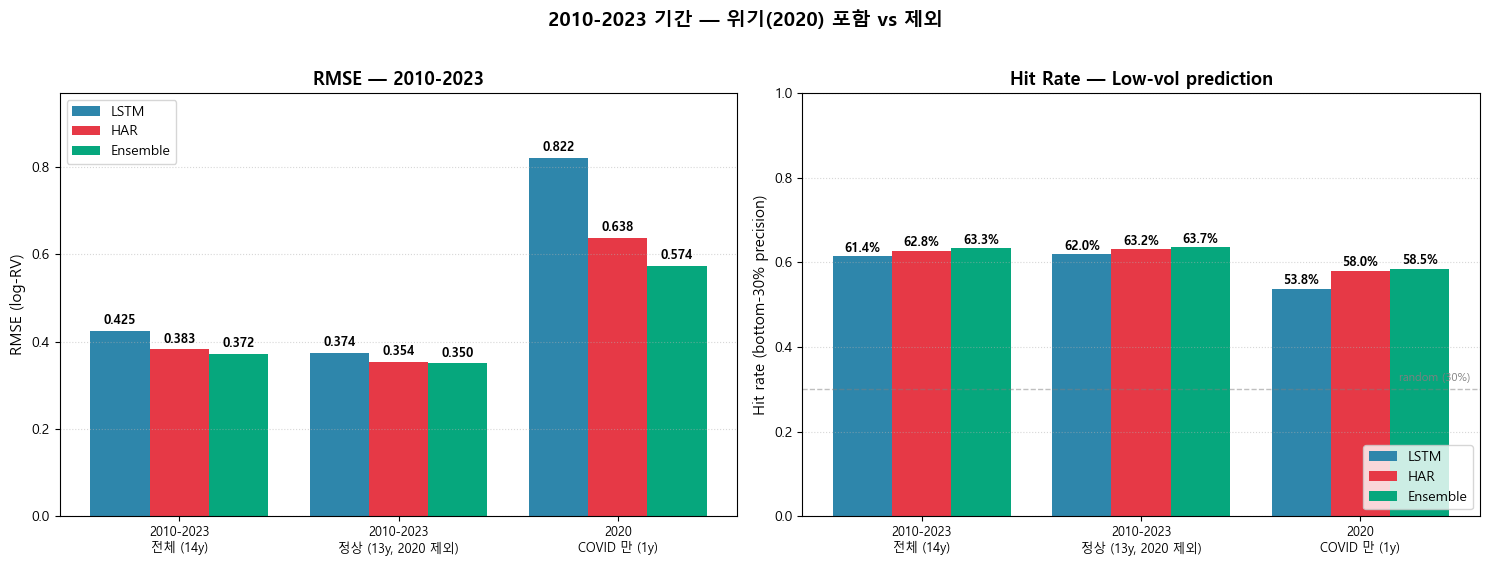


저장: outputs\03_volatility/fig_metrics_2010_2023.png


In [17]:
# §6.8 2010-2023 기간 RMSE + Hit Rate (위기 포함/제외 비교)
import numpy as np
import pandas as pd

# df 는 §1 에서 로드된 ensemble_predictions_stockwise.csv
# 필수 컬럼: date, ticker, y_true, y_pred_lstm, y_pred_har, y_pred_ensemble

df_e = df.copy()
df_e['date'] = pd.to_datetime(df_e['date'])
df_e['year'] = df_e['date'].dt.year

# ±inf 제거
for col in ['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble']:
    df_e = df_e[np.isfinite(df_e[col])]

# 기간 정의
periods = {
    '2010-2023 전체 (14y)':       df_e[(df_e.year >= 2010) & (df_e.year <= 2023)],
    '2010-2023 정상 (13y, 2020 제외)':  df_e[(df_e.year >= 2010) & (df_e.year <= 2023) & (df_e.year != 2020)],
    '2020 COVID 만 (1y)':         df_e[df_e.year == 2020],
}

def rmse(a, p):
    return float(np.sqrt(np.mean((a - p) ** 2)))

def hit_rate_q30(d, pred_col, q=0.30):
    """Cross-sectional bottom-q / top-q hit rate (날짜별 평균)."""
    lo_hits, lo_n, hi_hits, hi_n = 0, 0, 0, 0
    for _, g in d.groupby('date'):
        if len(g) < 10: continue
        t_lo = g['y_true'].quantile(q);     t_hi = g['y_true'].quantile(1 - q)
        p_lo = g[pred_col].quantile(q);     p_hi = g[pred_col].quantile(1 - q)
        pm_lo = g[pred_col] <= p_lo;        pm_hi = g[pred_col] >= p_hi
        tm_lo = g['y_true'] <= t_lo;        tm_hi = g['y_true'] >= t_hi
        lo_hits += (pm_lo & tm_lo).sum();   lo_n += pm_lo.sum()
        hi_hits += (pm_hi & tm_hi).sum();   hi_n += pm_hi.sum()
    return (lo_hits / lo_n if lo_n else np.nan,
            hi_hits / hi_n if hi_n else np.nan)

# ────────────────────────────────────────────
# RMSE 표
# ────────────────────────────────────────────
print('=' * 70)
print('RMSE — 2010-2023 기간 (위기 포함/제외)')
print('=' * 70)
rmse_rows = []
for label, sub in periods.items():
    rmse_rows.append({
        '기간':     label,
        'N (천)':   len(sub) / 1000,
        'N_dates':  sub.date.nunique(),
        'LSTM':     rmse(sub.y_true.values, sub.y_pred_lstm.values),
        'HAR':      rmse(sub.y_true.values, sub.y_pred_har.values),
        'Ensemble': rmse(sub.y_true.values, sub.y_pred_ensemble.values),
    })
rmse_df = pd.DataFrame(rmse_rows).set_index('기간')
print(rmse_df.round(4).to_string())

# ────────────────────────────────────────────
# Hit rate 표 (cross-sectional q=0.30)
# ────────────────────────────────────────────
print()
print('=' * 70)
print('Hit Rate — cross-sectional bottom-30 / top-30 precision')
print('=' * 70)
hr_rows = []
for label, sub in periods.items():
    row = {'기간': label}
    for model, pcol in [('LSTM', 'y_pred_lstm'),
                        ('HAR',  'y_pred_har'),
                        ('Ens',  'y_pred_ensemble')]:
        lo, hi = hit_rate_q30(sub, pcol, q=0.30)
        row[f'{model}_low']  = lo
        row[f'{model}_high'] = hi
    hr_rows.append(row)
hr_df = pd.DataFrame(hr_rows).set_index('기간')
print(hr_df.round(4).to_string())

# ────────────────────────────────────────────
# 시각화 (2 panels)
# ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: RMSE
ax = axes[0]
x = np.arange(len(rmse_df))
w = 0.27
ax.bar(x - w, rmse_df['LSTM'].values,     w, label='LSTM',     color='#2E86AB')
ax.bar(x,     rmse_df['HAR'].values,      w, label='HAR',      color='#E63946')
ax.bar(x + w, rmse_df['Ensemble'].values, w, label='Ensemble', color='#06A77D')
for i, lbl in enumerate(rmse_df.index):
    for col, dx in [('LSTM', -w), ('HAR', 0), ('Ensemble', w)]:
        v = rmse_df.loc[lbl, col]
        ax.text(i + dx, v + 0.015, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' ', '\n', 1) for l in rmse_df.index], fontsize=9)
ax.set_ylabel('RMSE (log-RV)', fontsize=11)
ax.set_title('RMSE — 2010-2023', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_ylim(0, rmse_df[['LSTM', 'HAR', 'Ensemble']].values.max() * 1.18)

# Right: Hit rate (low-vol prediction)
ax = axes[1]
ax.bar(x - w, hr_df['LSTM_low'].values, w, label='LSTM',     color='#2E86AB')
ax.bar(x,     hr_df['HAR_low'].values,  w, label='HAR',      color='#E63946')
ax.bar(x + w, hr_df['Ens_low'].values,  w, label='Ensemble', color='#06A77D')
for i, lbl in enumerate(hr_df.index):
    for col, dx in [('LSTM_low', -w), ('HAR_low', 0), ('Ens_low', w)]:
        v = hr_df.loc[lbl, col]
        ax.text(i + dx, v + 0.01, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(0.30, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(len(hr_df) - 0.5, 0.32, 'random (30%)', ha='right', fontsize=8, color='gray', style='italic')
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' ', '\n', 1) for l in hr_df.index], fontsize=9)
ax.set_ylabel('Hit rate (bottom-30% precision)', fontsize=11)
ax.set_title('Hit Rate — Low-vol prediction', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_ylim(0, 1.0)

plt.suptitle('2010-2023 기간 — 위기(2020) 포함 vs 제외', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_metrics_2010_2023.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'\n저장: {OUT_DIR}/fig_metrics_2010_2023.png')

§6.9 위기 시 ensemble 가중치 변화 분석
------------------------------------------------------------

[w_lstm 평균 - 위기 vs 정상]
  위기 3y (2008+09+20): w_lstm = 0.4401
  정상 16y:              w_lstm = 0.4975
  전체 19y:              w_lstm = 0.4888

[2010-2023 기준]
  COVID 만 (2020):       w_lstm = 0.4782
  정상 13y (COVID 제외): w_lstm = 0.4964
  전체 14y (2010-2023):  w_lstm = 0.4950


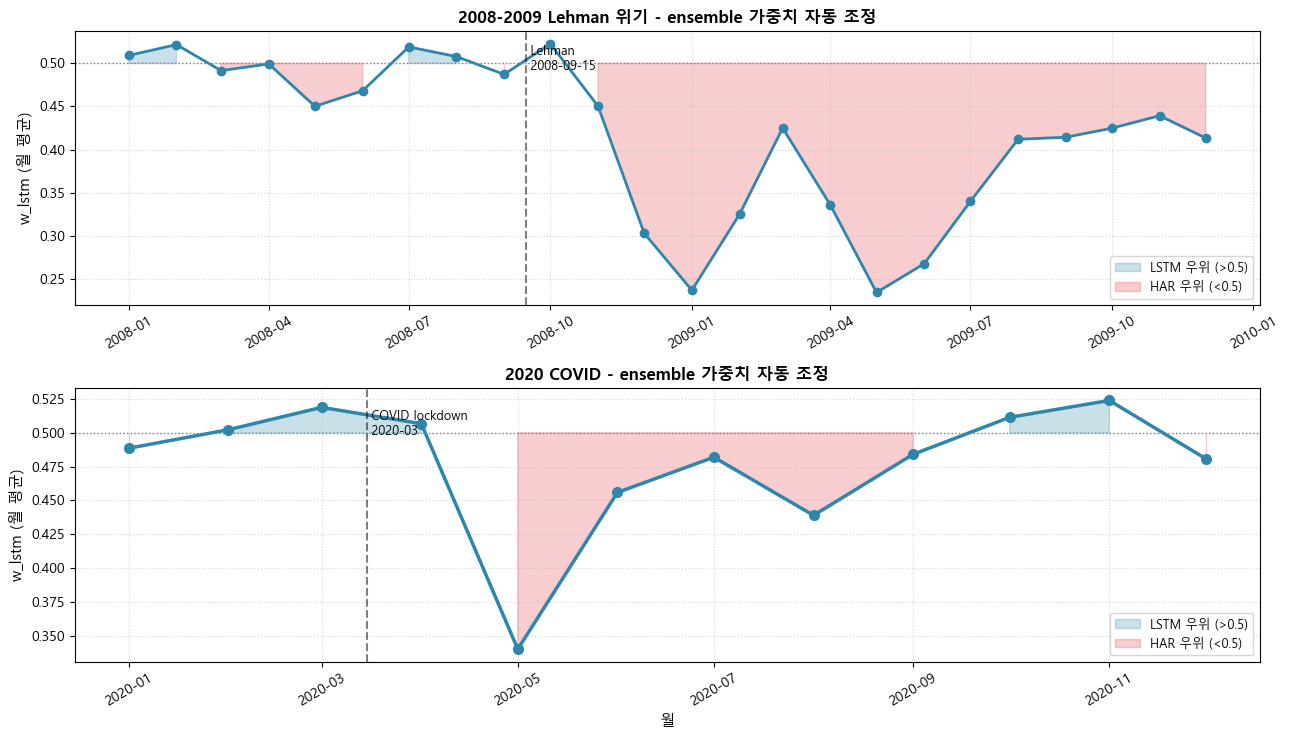


저장: outputs\03_volatility/fig_ensemble_weights_crisis.png


In [18]:
# §6.9 위기 시 ensemble 가중치 자동 조정 분석
# inverse-RMSE 가중이 위기에 LSTM 비중을 자동으로 낮추는지 검증
print("§6.9 위기 시 ensemble 가중치 변화 분석")
print("-" * 60)

df_w2 = df[['date', 'w_v4']].copy()
df_w2['date'] = pd.to_datetime(df_w2['date'])
df_w2['year'] = df_w2['date'].dt.year

CRISIS_YEARS = [2008, 2009, 2020]
crisis_mask = df_w2['year'].isin(CRISIS_YEARS)

print()
print('[w_lstm 평균 - 위기 vs 정상]')
print(f'  위기 3y (2008+09+20): w_lstm = {df_w2[crisis_mask].w_v4.mean():.4f}')
print(f'  정상 16y:              w_lstm = {df_w2[~crisis_mask].w_v4.mean():.4f}')
print(f'  전체 19y:              w_lstm = {df_w2.w_v4.mean():.4f}')

# 2010-2023 기준 분리
mask_decade = (df_w2.year >= 2010) & (df_w2.year <= 2023)
print()
print('[2010-2023 기준]')
print(f'  COVID 만 (2020):       w_lstm = {df_w2[df_w2.year==2020].w_v4.mean():.4f}')
print(f'  정상 13y (COVID 제외): w_lstm = {df_w2[mask_decade & (df_w2.year != 2020)].w_v4.mean():.4f}')
print(f'  전체 14y (2010-2023):  w_lstm = {df_w2[mask_decade].w_v4.mean():.4f}')

# 시각화 — 위기 구간 zoom + LSTM RMSE 와 w_lstm 비교
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=False)

# Top: 2008-2009 (Lehman) zoom
ax = axes[0]
mask_0809 = df_w2.year.isin([2008, 2009])
df_w_0809 = df_w2[mask_0809].copy()
df_w_0809['ym'] = df_w_0809['date'].dt.to_period('M').dt.to_timestamp()
w_0809 = df_w_0809.groupby('ym')['w_v4'].mean()
ax.plot(w_0809.index, w_0809.values, marker='o', markersize=6, color='#2E86AB', linewidth=2)
ax.fill_between(w_0809.index, 0.5, w_0809.values,
                where=(w_0809.values > 0.5), color='#2E86AB', alpha=0.25, label='LSTM 우위 (>0.5)')
ax.fill_between(w_0809.index, 0.5, w_0809.values,
                where=(w_0809.values < 0.5), color='#E63946', alpha=0.25, label='HAR 우위 (<0.5)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.axvline(pd.Timestamp('2008-09-15'), color='black', linestyle='--', alpha=0.5)
ax.text(pd.Timestamp('2008-09-15'), ax.get_ylim()[1]*0.97, ' Lehman\n 2008-09-15',
        fontsize=9, color='black', va='top')
ax.set_ylabel('w_lstm (월 평균)', fontsize=11)
ax.set_title('2008-2009 Lehman 위기 - ensemble 가중치 자동 조정',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(linestyle=':', alpha=0.5)
ax.tick_params(axis='x', rotation=30)

# Bottom: 2020 (COVID) zoom
ax = axes[1]
mask_2020 = df_w2.year == 2020
df_w_20 = df_w2[mask_2020].copy()
df_w_20['ym'] = df_w_20['date'].dt.to_period('M').dt.to_timestamp()
w_20 = df_w_20.groupby('ym')['w_v4'].mean()
ax.plot(w_20.index, w_20.values, marker='o', markersize=7, color='#2E86AB', linewidth=2.5)
ax.fill_between(w_20.index, 0.5, w_20.values,
                where=(w_20.values > 0.5), color='#2E86AB', alpha=0.25, label='LSTM 우위 (>0.5)')
ax.fill_between(w_20.index, 0.5, w_20.values,
                where=(w_20.values < 0.5), color='#E63946', alpha=0.25, label='HAR 우위 (<0.5)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.axvline(pd.Timestamp('2020-03-15'), color='black', linestyle='--', alpha=0.5)
ax.text(pd.Timestamp('2020-03-15'), ax.get_ylim()[1]*0.97, ' COVID lockdown\n 2020-03',
        fontsize=9, color='black', va='top')
ax.set_xlabel('월', fontsize=11)
ax.set_ylabel('w_lstm (월 평균)', fontsize=11)
ax.set_title('2020 COVID - ensemble 가중치 자동 조정',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(linestyle=':', alpha=0.5)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_ensemble_weights_crisis.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'\n저장: {OUT_DIR}/fig_ensemble_weights_crisis.png')


## §7. 결과 검증 + 종합 요약

전체 종목 stockwise 평균 RMSE 측정값 출력 + summary.json 저장.

In [19]:
# §7.1 핵심 수치
print('§7.1 핵심 수치')
print('-' * 60)

metrics = {
    'lstm_rmse': float(rmse_full['lstm'].mean()),
    'har_rmse': float(rmse_full['har'].mean()),
    'ensemble_rmse': float(rmse_full['ens'].mean()),
    'n_tickers': int(rmse_full.shape[0]),
    'best_ensemble_count': int(best_per_ticker.get('ens', 0)),
    'best_har_count': int(best_per_ticker.get('har', 0)),
    'best_lstm_count': int(best_per_ticker.get('lstm', 0)),
}

print()
print('현재 측정값:')
for k in ['lstm_rmse', 'har_rmse', 'ensemble_rmse']:
    print(f'  {k}: {metrics[k]:.4f}')


§7.1 핵심 수치
------------------------------------------------------------

현재 측정값:
  lstm_rmse: 0.5185
  har_rmse: 0.3914
  ensemble_rmse: 0.3822


In [20]:
# §7.2 summary.json 저장
print()
print("§7.2 summary.json 저장")
print("-" * 60)

summary = {
    'notebook': '03b_Volatility_Forecasting',
    'csv_md5': md5,
    'n_tickers': metrics['n_tickers'],
    'date_range': f"{df['date'].min().date()} ~ {df['date'].max().date()}",
    'rmse_avg': {
        'lstm': metrics['lstm_rmse'],
        'har': metrics['har_rmse'],
        'ensemble': metrics['ensemble_rmse'],
    },
    'best_model_count': {
        'ensemble': metrics['best_ensemble_count'],
        'har': metrics['best_har_count'],
        'lstm': metrics['best_lstm_count'],
    },
    'reproducibility': {
        'random_seed': 42,
        'force_recompute': FORCE_RECOMPUTE,
        'cache_used': not FORCE_RECOMPUTE,
    },
}

with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"저장: {OUT_DIR}/summary.json")
print()
print(json.dumps(summary, indent=2, ensure_ascii=False))


§7.2 summary.json 저장
------------------------------------------------------------
저장: outputs\03_volatility/summary.json

{
  "notebook": "03b_Volatility_Forecasting",
  "csv_md5": "276a5e143fbed8a852e0d76618401b5b",
  "n_tickers": 617,
  "date_range": "2007-04-23 ~ 2026-02-27",
  "rmse_avg": {
    "lstm": 0.5184841843264669,
    "har": 0.3913507875060677,
    "ensemble": 0.3821595196001218
  },
  "best_model_count": {
    "ensemble": 403,
    "har": 200,
    "lstm": 14
  },
  "reproducibility": {
    "random_seed": 42,
    "force_recompute": false,
    "cache_used": true
  }
}


In [21]:
# §7.3 종합 메시지
n_folds_total = df['fold'].nunique()
print()
print("=" * 60)
print(f"{n_tickers} 종목 stockwise LSTM + HAR Ensemble 검증 완료")
print("=" * 60)
print(f"  ✓ csv md5: {md5}")
print(f"  ✓ 종목 수 {metrics['n_tickers']} ⊂ universe {n_universe}")
print(f"  ✓ Walk-Forward {n_folds_total} fold × 종목별 학습 결과 활용")
print(f"  ✓ Performance-Weighted Ensemble best in {metrics['best_ensemble_count']} 종목 ({metrics['best_ensemble_count']/metrics['n_tickers']*100:.1f}%)")
print()
print(f"다음 단계: 07_Statistical_Validation.ipynb 에서 학술 통계 심화 분석")


617 종목 stockwise LSTM + HAR Ensemble 검증 완료
  ✓ csv md5: 276a5e143fbed8a852e0d76618401b5b
  ✓ 종목 수 617 ⊂ universe 833
  ✓ Walk-Forward 225 fold × 종목별 학습 결과 활용
  ✓ Performance-Weighted Ensemble best in 403 종목 (65.3%)

다음 단계: 07_Statistical_Validation.ipynb 에서 학술 통계 심화 분석


## §8. 종합 요약 + 롤백 가이드

노트북 실행 모드 (cache hit / FORCE_RECOMPUTE) 와 갱신된 산출물 위치를 최종 정리. 재학습 결과에 문제가 생긴 경우 복원 경로 안내.

In [22]:
# §8.1 종합 요약 + 롤백 가이드
print('=' * 70)
print(' 03b_Volatility_Forecasting 완료')
print('=' * 70)
print()
print(f'FORCE_RECOMPUTE: {FORCE_RECOMPUTE}')
print()
print(f'ensemble csv   : {CSV_PATH.name}')
print(f'  shape        : {df.shape}')
print(f'  date range   : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  종목 수       : {df["ticker"].nunique()}')
print()
if FORCE_RECOMPUTE:
    print('✅ 재학습 + ensemble 빌드 완료')
    print()
    print('🛡 롤백 (학습 결과 문제 시):')
    print('  - data/03b_lstm/data/ensemble_predictions_stockwise.csv.bak_pre_retrain_2025_12 → 복원')
    print('  - data/03b_lstm/data/fold_predictions_stockwise.csv.bak_pre_retrain → 복원')
else:
    print('✅ Cache hit 모드 검증 완료')
    print()
    print('재학습이 필요하면 FORCE_RECOMPUTE = True 로 변경 후 재실행')

 03b_Volatility_Forecasting 완료

FORCE_RECOMPUTE: False

ensemble csv   : ensemble_predictions_stockwise.csv
  shape        : (2498216, 9)
  date range   : 2007-04-23 ~ 2026-02-27
  종목 수       : 617

✅ Cache hit 모드 검증 완료

재학습이 필요하면 FORCE_RECOMPUTE = True 로 변경 후 재실행
